In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# загрузка файла с одним листом
file_path = r'C:\Users\silen\OneDrive\Рабочий стол\учеба\СОИ\пр4\hcpi_m.xlsx'

# Чтение файла
df = pd.read_excel(file_path)

# проверяем структуру
df.head()

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,197001,197002,197003,197004,197005,...,202408,202409,202410,202411,202412,202501,202502,202503,Data source,Note
0,ABW,314.0,Aruba,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IFS,NaN
1,AFG,512.0,Afghanistan,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,125.809803,126.488546,127.263109,126.780158,128.366370,128.508266,NaN,NaN,IFS,NaN
2,AGO,614.0,Angola,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,207.504380,210.879490,214.157277,217.594986,221.293056,224.993357,NaN,NaN,National sources,NaN
3,ALB,914.0,Albania,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,116.775018,117.505130,117.630071,117.603379,118.251031,118.684513,119.053412,NaN,IFS,NaN
4,ARE,466.0,United Arab Emirates,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,108.820028,108.698979,108.362584,108.748894,108.849868,NaN,NaN,NaN,IFS,NaN


In [3]:
# выбираем Японию
japan = df[
    (df['Country'] == 'Japan') &
    (df['Series Name'] == 'Headline Consumer Price Index')
]

# выбор строки для Японии
japan = df[
    (df['Country'] == 'Japan') &
    (df['Series Name'] == 'Headline Consumer Price Index')
]

# выделение месячных столбцов
date_cols = [c for c in japan.columns if isinstance(c, int)]
japan_ts = japan[date_cols].T
japan_ts.columns = ['HCPI']
japan_ts.index = pd.to_datetime(japan_ts.index.astype(str), format='%Y%m')
japan_ts = japan_ts.sort_index().dropna()

# показать первые и последние строки
display(japan_ts.head())
display(japan_ts.tail())


,HCPI
1970-01-01,30.257409
1970-02-01,30.355648
1970-03-01,30.650363
1970-04-01,30.945078
1970-05-01,30.748601


,HCPI
2024-10-01,109.5
2024-11-01,110.0
2024-12-01,110.7
2025-01-01,111.2
2025-02-01,110.8


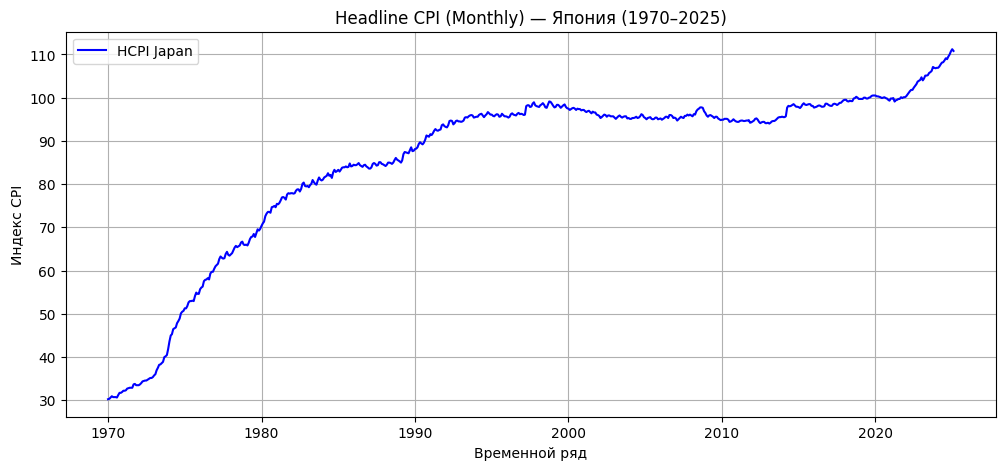

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(japan_ts.index, japan_ts['HCPI'], color='blue', label='HCPI Japan')
plt.xlabel('Временной ряд')
plt.ylabel('Индекс CPI')
plt.title('Headline CPI (Monthly) — Япония (1970–2025)')
plt.legend()
plt.grid(True)
plt.show()

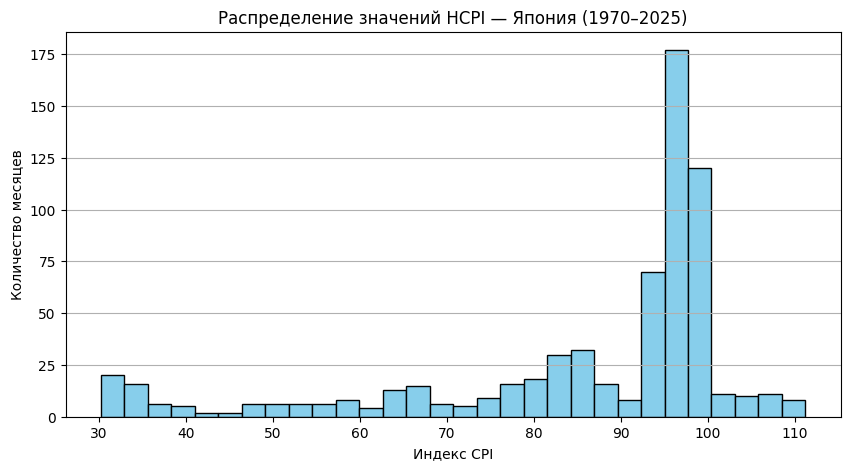

In [5]:
plt.figure(figsize=(10,5))
plt.hist(japan_ts['HCPI'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Индекс CPI')
plt.ylabel('Количество месяцев')
plt.title('Распределение значений HCPI — Япония (1970–2025)')
plt.grid(axis='y')
plt.show()

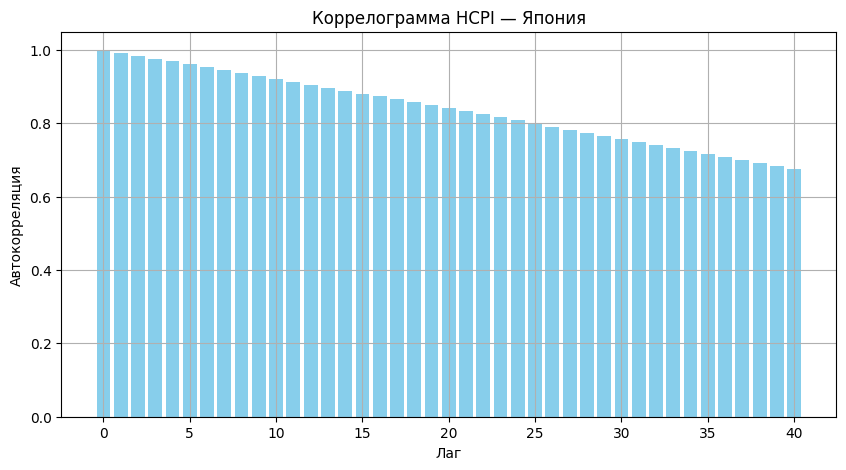

ADF Statistic: -3.2034245222153044
p-value: 0.019787308193442318


In [6]:
from statsmodels.tsa.stattools import acf, adfuller

# 1. Автокорреляции
lag_acf = acf(japan_ts['HCPI'], nlags=40)  # до 40 месяцев
lags = range(len(lag_acf))

# 2. Построение коррелограммы
plt.figure(figsize=(10,5))
plt.bar(lags, lag_acf, color='skyblue')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.title('Коррелограмма HCPI — Япония')
plt.grid(True)
plt.show()

# 3. Дополнительно: тест Дики-Фуллера
adf_result = adfuller(japan_ts['HCPI'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


In [7]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Добавим константу для регрессии на тренд
t = range(len(japan_ts))
X = sm.add_constant(t)
y = japan_ts['HCPI']

# Линейная регрессия ряда по времени
model = sm.OLS(y, X).fit()

# Тест Дарбина-Уотсона
dw_stat = durbin_watson(model.resid)
print("Durbin-Watson statistic:", dw_stat)


Durbin-Watson statistic: 0.0014048080727716119


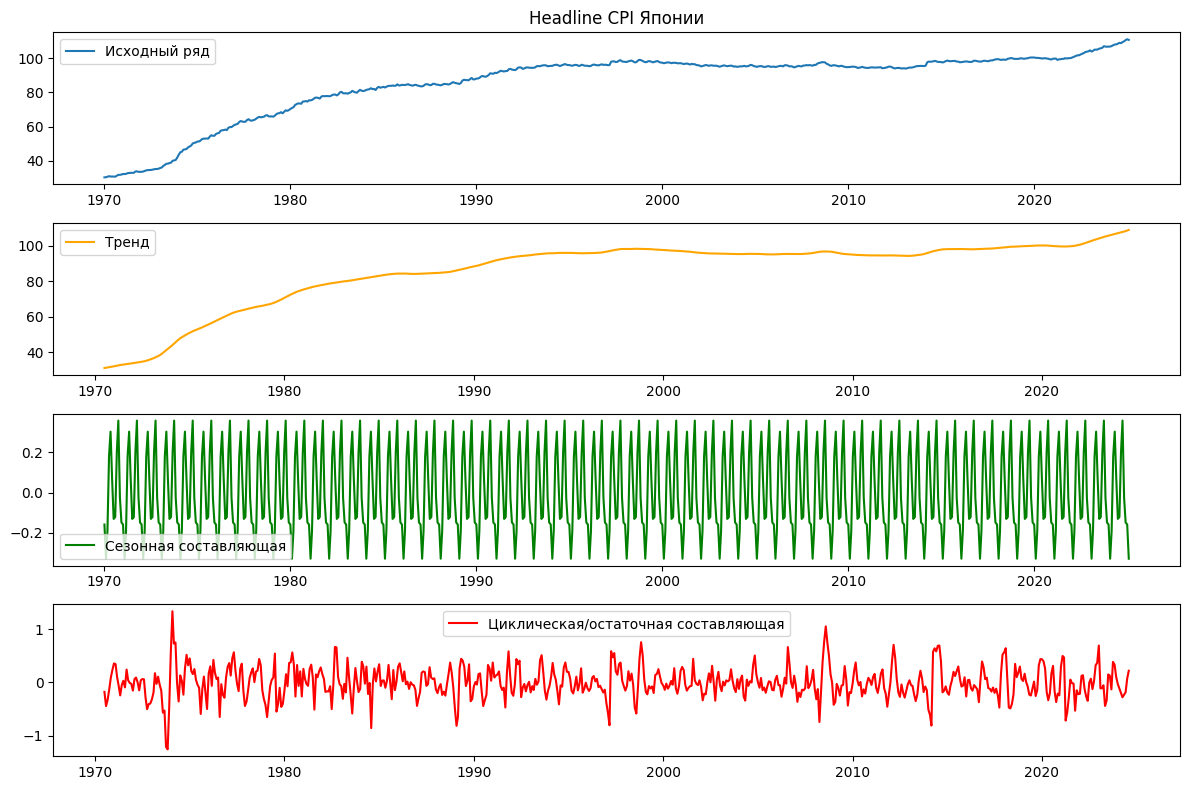

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Разложение ряда (additive — сложение компонентов)
decomposition = seasonal_decompose(japan_ts['HCPI'], model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Графики
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(japan_ts.index, japan_ts['HCPI'], label='Исходный ряд')
plt.title('Headline CPI Японии')
plt.legend()

plt.subplot(4,1,2)
plt.plot(trend, label='Тренд', color='orange')
plt.legend()

plt.subplot(4,1,3)
plt.plot(seasonal, label='Сезонная составляющая', color='green')
plt.legend()

plt.subplot(4,1,4)
plt.plot(residual, label='Циклическая/остаточная составляющая', color='red')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Разложение ряда (месячные данные, период=12)
decomposition = seasonal_decompose(japan_ts['HCPI'], model='additive', period=12)

# Создаём таблицу
components = pd.DataFrame({
    'CPI': japan_ts['HCPI'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
})

# Добавляем проверку суммы
components['Sum_Check'] = components['Trend'] + components['Seasonal'] + components['Residual']

# Выводим первые и последние 5 строк
print("Начало ряда:")
print(components.head())
print("\nКонец ряда:")
print(components.tail())


Начало ряда:
                  CPI  Trend  Seasonal  Residual  Sum_Check
1970-01-01  30.257409    NaN -0.158794       NaN        NaN
1970-02-01  30.355648    NaN -0.328744       NaN        NaN
1970-03-01  30.650363    NaN -0.191873       NaN        NaN
1970-04-01  30.945078    NaN  0.180857       NaN        NaN
1970-05-01  30.748601    NaN  0.303002       NaN        NaN

Конец ряда:
              CPI  Trend  Seasonal  Residual  Sum_Check
2024-10-01  109.5    NaN  0.358026       NaN        NaN
2024-11-01  110.0    NaN -0.025259       NaN        NaN
2024-12-01  110.7    NaN -0.148442       NaN        NaN
2025-01-01  111.2    NaN -0.158794       NaN        NaN
2025-02-01  110.8    NaN -0.328744       NaN        NaN


In [10]:
components_clean = components.dropna()
components_clean.index = components_clean.index.to_period('M')
# Вывод первых и последних 5 строк
print("Начало ряда без NaN:")
print(components_clean.head())
print("\nКонец ряда:")
print(components_clean.tail())

Начало ряда без NaN:
               CPI      Trend  Seasonal  Residual  Sum_Check
1970-07  30.748601  31.059689 -0.130872 -0.180216  30.748601
1970-08  30.650363  31.219326 -0.121721 -0.447243  30.650363
1970-09  31.239793  31.366684  0.198945 -0.325837  31.239793
1970-10  31.730984  31.509948  0.358026 -0.136989  31.730984
1970-11  31.730984  31.669585 -0.025259  0.086658  31.730984

Конец ряда:
           CPI       Trend  Seasonal  Residual  Sum_Check
2024-04  107.7  107.800000  0.180857 -0.280857      107.7
2024-05  108.1  108.029167  0.303002 -0.232169      108.1
2024-06  108.2  108.320833  0.064875 -0.185709      108.2
2024-07  108.6  108.662500 -0.130872  0.068372      108.6
2024-08  109.1  109.004167 -0.121721  0.217554      109.1


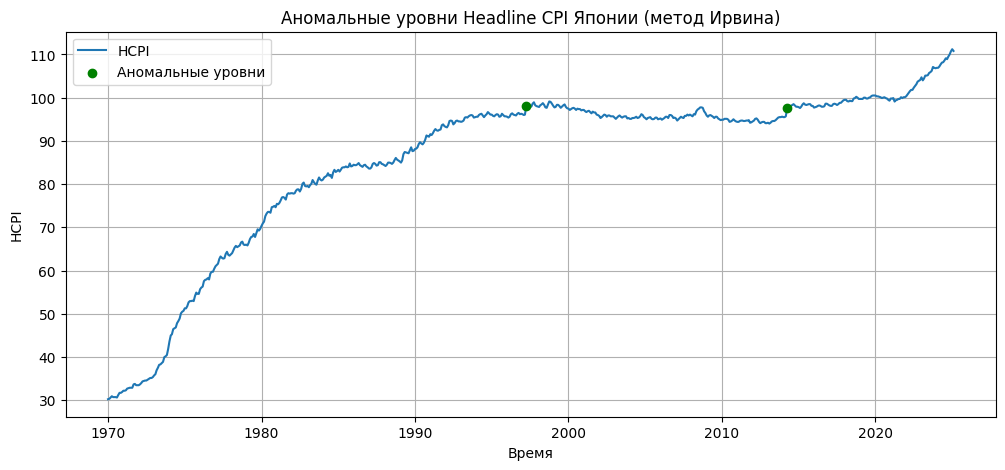

In [11]:
df_irwin = japan_ts.copy()

df_irwin['Delta'] = df_irwin['HCPI'].diff()

s = df_irwin['HCPI'].std()

df_irwin['Irwin_stat'] = df_irwin['Delta'].abs() / s

I_crit = 0.1

df_irwin['Anomaly'] = df_irwin['Irwin_stat'] > I_crit

anomalies = df_irwin[df_irwin['Anomaly']]

plt.figure(figsize=(12, 5))
plt.plot(df_irwin.index, df_irwin['HCPI'], label='HCPI')
plt.scatter(anomalies.index, anomalies['HCPI'], label='Аномальные уровни', color = 'green', zorder=5)
plt.title('Аномальные уровни Headline CPI Японии (метод Ирвина)')
plt.xlabel('Время')
plt.ylabel('HCPI')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
df_irwin['Anomaly'].sum()

np.int64(2)

In [13]:
df_irwin[['HCPI', 'Delta', 'Irwin_stat']].head(10)

,HCPI,Delta,Irwin_stat
1970-01-01,30.257409,NaN,NaN
1970-02-01,30.355648,0.098238,0.005081
1970-03-01,30.650363,0.294715,0.015242
1970-04-01,30.945078,0.294715,0.015242
1970-05-01,30.748601,-0.196477,0.010161
1970-06-01,30.748601,0.000000,0.000000
1970-07-01,30.748601,0.000000,0.000000
1970-08-01,30.650363,-0.098238,0.005081
1970-09-01,31.239793,0.589430,0.030484
1970-10-01,31.730984,0.491192,0.025403


In [14]:
# метод сравнения средних
n = len(japan_ts)
first_half = japan_ts['HCPI'].iloc[:n//2]
second_half = japan_ts['HCPI'].iloc[n//2:]

mean_first = first_half.mean()
mean_second = second_half.mean()

mean_first, mean_second

(np.float64(73.38493182849898), np.float64(97.94750716152967))

In [15]:
# метод Фостера–Стюарта
diff = japan_ts['HCPI'].diff().dropna()

S = diff.sum()
sigma = diff.std()

FS_stat = S / sigma
FS_stat


np.float64(203.16395690953092)

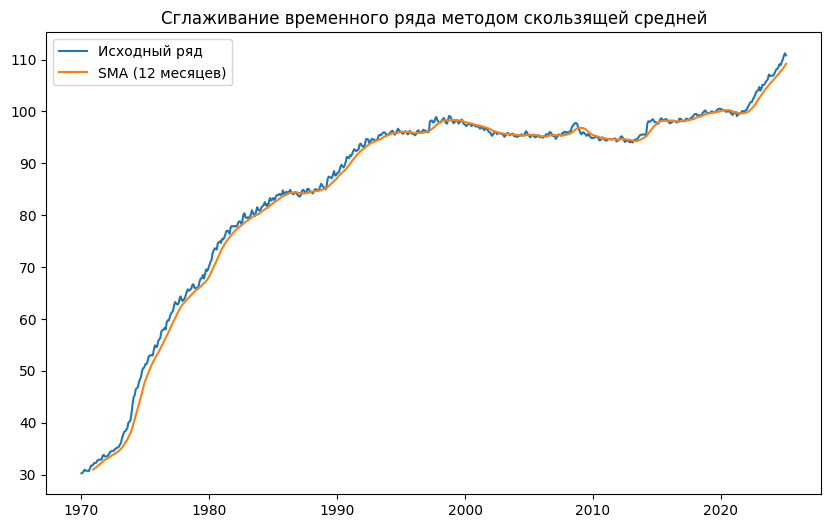

In [16]:
# простая скользящая средняя (12 месяцев)
japan_ts['SMA_12'] = japan_ts['HCPI'].rolling(window=12).mean()

# визуализация
plt.figure(figsize=(10, 6))
plt.plot(japan_ts['HCPI'], label='Исходный ряд')
plt.plot(japan_ts['SMA_12'], label='SMA (12 месяцев)')
plt.legend()
plt.title('Сглаживание временного ряда методом скользящей средней')
plt.show()

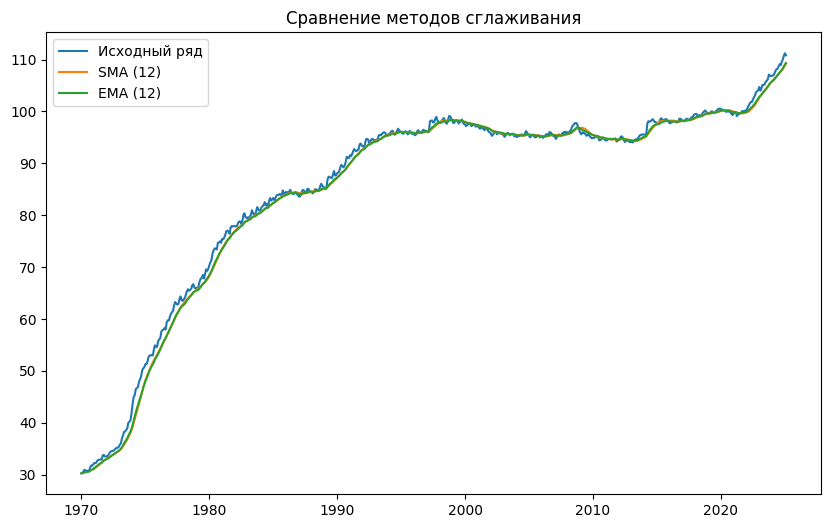

In [17]:
# экспоненциальное сглаживание
japan_ts['EMA_12'] = japan_ts['HCPI'].ewm(span=12, adjust=False).mean()

plt.figure(figsize=(10, 6))
plt.plot(japan_ts['HCPI'], label='Исходный ряд')
plt.plot(japan_ts['SMA_12'], label='SMA (12)')
plt.plot(japan_ts['EMA_12'], label='EMA (12)')
plt.legend()
plt.title('Сравнение методов сглаживания')
plt.show()


In [18]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

t = np.arange(len(japan_ts))
y = japan_ts['HCPI'].values

# 1. Линейная модель
lin_coef = np.polyfit(t, y, 1)
y_lin = np.polyval(lin_coef, t)

# 2. Полиномиальная 2 степени
poly2_coef = np.polyfit(t, y, 2)
y_poly2 = np.polyval(poly2_coef, t)

# 3. Экспоненциальная модель
log_y = np.log(y)
exp_coef = np.polyfit(t, log_y, 1)
y_exp = np.exp(exp_coef[1]) * np.exp(exp_coef[0] * t)

# Метрики
models = {
    'Линейная': y_lin,
    'Полиномиальная (2)': y_poly2,
    'Экспоненциальная': y_exp
}

for name, y_hat in models.items():
    r2 = r2_score(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    print(f'{name}: R² = {r2:.4f}, RMSE = {rmse:.2f}')


Линейная: R² = 0.6986, RMSE = 10.61
Полиномиальная (2): R² = 0.9139, RMSE = 5.67
Экспоненциальная: R² = 0.5648, RMSE = 12.75


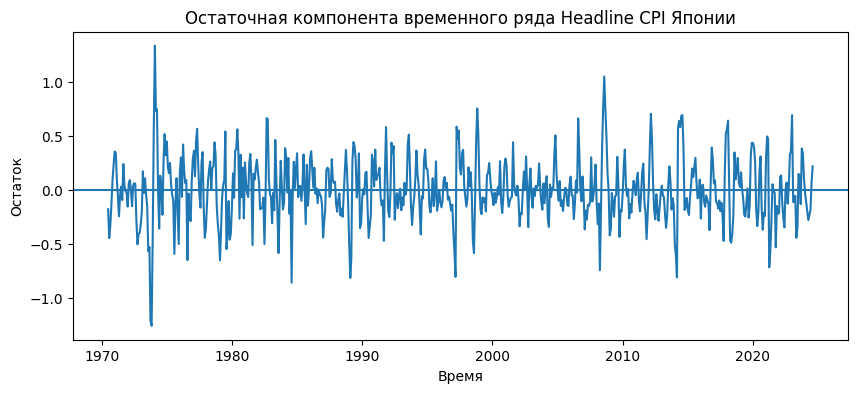

<Figure size 1000x400 with 0 Axes>

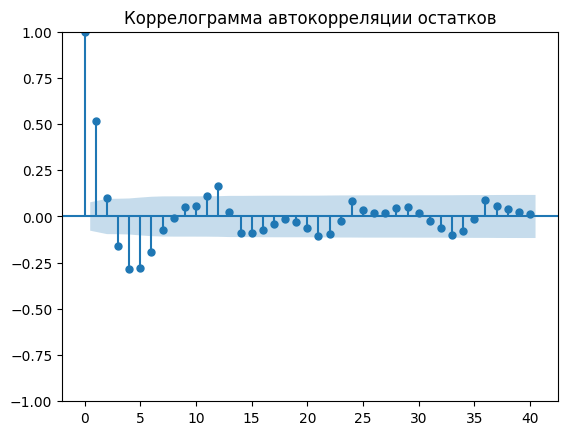

(np.float64(-0.0017410082401405162),
 np.float64(0.2894154058859261),
 np.float64(0.9598549981439797))

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

# берем остаточную компоненту
residuals = components['Residual'].dropna()

# ===== 1. График остаточной компоненты =====
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.axhline(0)
plt.title('Остаточная компонента временного ряда Headline CPI Японии')
plt.xlabel('Время')
plt.ylabel('Остаток')
plt.show()

# ===== 2. Коррелограмма остатков =====
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=40)
plt.title('Коррелограмма автокорреляции остатков')
plt.show()

# ===== 3. Числовые характеристики =====
mean_res = residuals.mean()
std_res = residuals.std()
dw_stat = durbin_watson(residuals)

mean_res, std_res, dw_stat